
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 1. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [2]:

# --- Imports
import os
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False


# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available




# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "C:/Users/to_fi/OneDrive/Documents/GitHub/Doutorado/Racing4all/Iracing/"
google_drive_path = "C:/Users/to_fi/OneDrive/Documents/Google Drive/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte"

#ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2026-01-22 14-13-43(Morsinaldo).ibt"
ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz

# --- Configuration ---
IBT_FILES = [
    Path(ibt_file)
]
# Laps to visualize in the "quick overlay" plots (only visualization; robust pipeline auto-selects reference)
laps_to_plot = [2, 3, 4]

# Core pipeline settings
N_SECTORS = 4               # number of sectors to split the track
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42




## 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [3]:


USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = [
        # Tempo / lap
        'SessionTime',
        'Lap',
        'LapDistPct',

        # Inputs
        'Throttle',
        'ThrottleRaw',
        'Brake',
        'BrakeRaw',
        'SteeringWheelAngle',

        # Dinâmica
        'Speed',
        'LatAccel',
        'LongAccel',
        'YawRate',

        # Contexto
        'RPM',
        'Gear',
        'BrakeABSactive',
    ]
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)


ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz
raw_df = load_from_ibt(Path(ibt_file))
raw_df.head()

,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False
1,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False
2,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False
3,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False
4,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False


# 3) Data Cleaning



In [4]:

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    max_lap_time_s: float = 120.0,
) -> pd.DataFrame:

    manual_invalid = manual_invalid or set()
    rows = []

    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        lap_time = lap_time_seconds(gs)

        rows.append({
            "Lap": int(lap),
            "LapTime_s": float(lap_time),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })

    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)

    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph) &
        (lap_df["LapTime_s"] <= max_lap_time_s)
    )
    lap_df["Valid"] = valid

    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        hi = float(q3 + 1.5 * iqr)
        lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)

    return lap_df



def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()

    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}

    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)

    out = {
        "t_rel": interp(t_rel.to_numpy()),

        # Cinemática
        "speed": interp(g["Speed_KPH"].to_numpy()),

        # Inputs
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),

        # Direção
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
    }

    # Dinâmica lateral / longitudinal
    if "LatAccel" in g.columns:
        out["LatAccel"] = interp(g["LatAccel"].to_numpy())
    if "LongAccel" in g.columns:
        out["LongAccel"] = interp(g["LongAccel"].to_numpy())
    if "YawRate" in g.columns:
        out["YawRate"] = interp(g["YawRate"].to_numpy())

    # Contexto (opcional)
    if "RPM" in g.columns:
        out["RPM"] = interp(g["RPM"].to_numpy())
    if "Gear" in g.columns:
        out["Gear"] = interp(g["Gear"].to_numpy())

    return out


def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0
    return df

In [5]:
tomaz_df = basic_clean_and_units(raw_df)
tomaz_df.head()

,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False,0.000000,0.0,100.0
1,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False,0.015679,0.0,100.0
2,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False,0.020651,0.0,100.0
3,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False,0.084890,0.0,100.0
4,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False,0.141674,0.0,100.0



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [6]:
INVALID_LAPS = set()
TARGET_LAP_TO_ANALYZE = 4

lap_df = build_lap_validity_table(tomaz_df, manual_invalid=INVALID_LAPS)

lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)

display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

# --- Referência: volta mais rápida válida ---
ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# --- Target: tentativa manual com fallback ---
target_lap = TARGET_LAP_TO_ANALYZE

if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não existe ou é inválida.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,2917.466667,48:37.467
1,1,True,98.266667,01:38.267
2,2,True,99.416667,01:39.417
3,3,True,98.083333,01:38.083
4,4,True,97.283333,01:37.283
5,5,False,100.250000,01:40.250
6,6,True,97.933333,01:37.933
7,7,True,97.283333,01:37.283
8,8,True,99.066667,01:39.067
9,9,True,98.400000,01:38.400


Reference lap: 19  (01:36.733)
Target lap   : 4  (01:37.283)


# Import other driver telemetry

In [7]:
# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "C:/Users/to_fi/OneDrive/Documents/GitHub/Doutorado/Racing4all/Iracing/"
google_drive_path = "C:/Users/to_fi/OneDrive/Documents/Google Drive/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte"

ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2026-01-22 14-13-43(Morsinaldo).ibt"

raw_morsinaldo_df = load_from_ibt(Path(ibt_file))
#Data Cleaning
morsinaldo_df = basic_clean_and_units(raw_morsinaldo_df)
morsinaldo_df.head()



,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,1005.316667,7,0.533380,1.0,1.0,0.0,0.0,0.26203,42.736897,6.746342,1.208181,0.245570,5852.667969,4,False,153.852827,100.0,0.0
1,1005.333333,7,0.533576,1.0,1.0,0.0,0.0,0.26203,42.759254,7.144814,1.152904,0.242473,5848.663574,4,False,153.933316,100.0,0.0
2,1005.350000,7,0.533773,1.0,1.0,0.0,0.0,0.26203,42.780228,6.269738,1.030190,0.240770,5850.027344,4,False,154.008820,100.0,0.0
3,1005.366667,7,0.533970,1.0,1.0,0.0,0.0,0.26203,42.802505,6.867212,1.081871,0.240304,5857.299316,4,False,154.089020,100.0,0.0
4,1005.383333,7,0.534167,1.0,1.0,0.0,0.0,0.26203,42.822609,6.901429,1.098787,0.239934,5861.611328,4,False,154.161392,100.0,0.0


In [8]:
#Cleaning lap time
INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
target_lap = 10 # Tentativa de usar a volta desejada


#retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(morsinaldo_df, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

# Volta de referência (mais rápida válida)
ref_row_morsinaldo = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row_morsinaldo["Lap"])


if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não disponível para este piloto.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)
    
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,7506.266667,125:06.267
1,7,False,45.333333,00:45.333
2,8,True,103.933333,01:43.933
3,9,True,104.483333,01:44.483
4,10,True,104.850000,01:44.850
...,...,...,...,...
63,69,True,113.550000,01:53.550
64,70,True,106.666667,01:46.667
65,71,True,104.933333,01:44.933
66,72,False,185.133333,03:05.133


Reference lap: 65  (01:36.733)
Target lap   : 10  (01:44.850)



## 5. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


Piloto A - Best lap: 19 (01:36.733)
Piloto B - Best lap: 65 (01:39.817)


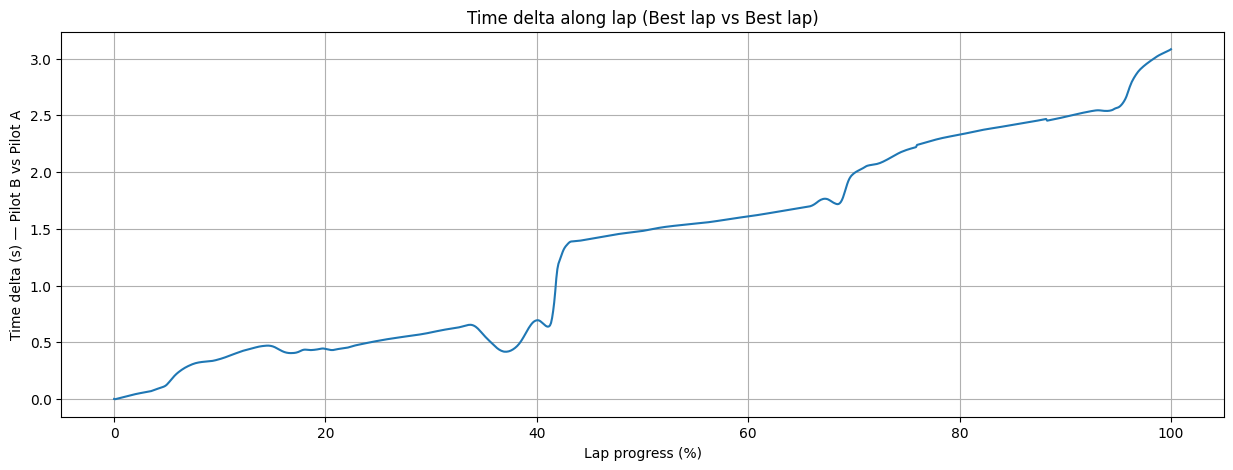

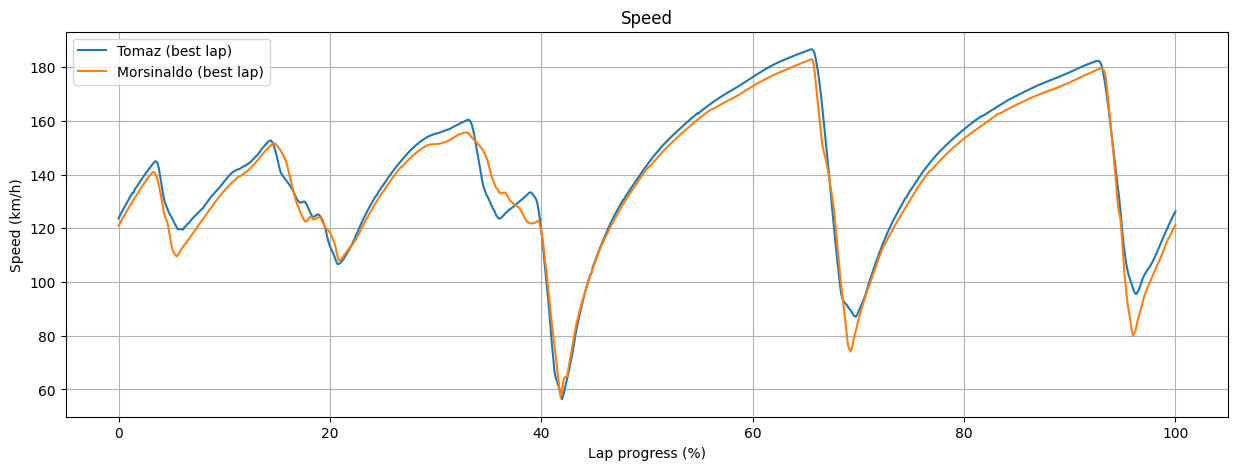

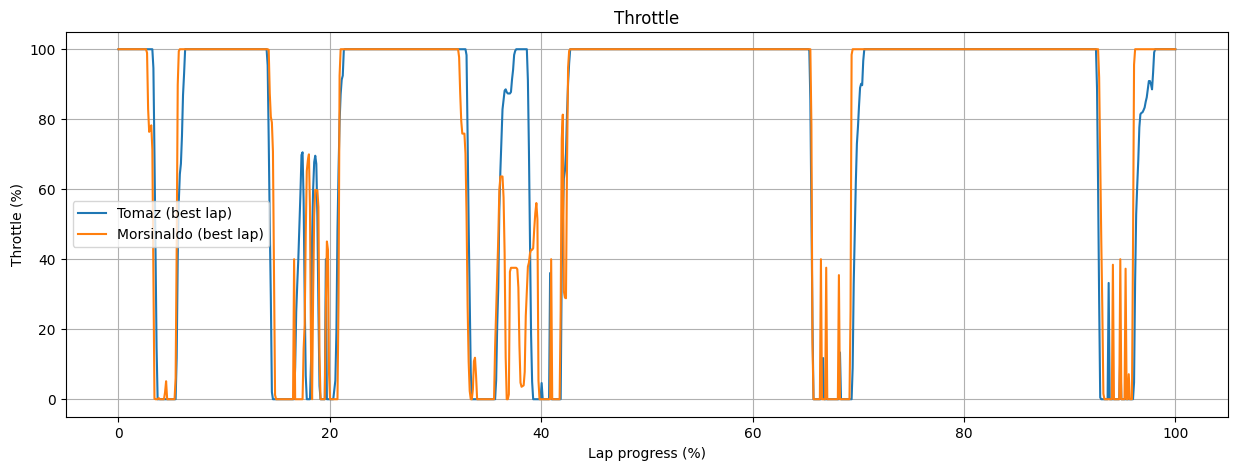

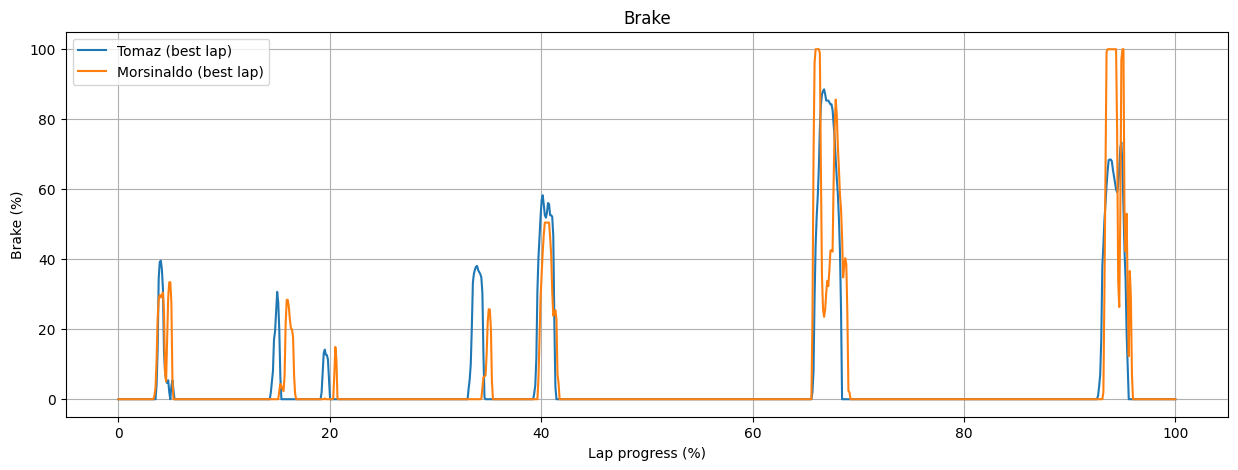

In [9]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")




## 6. Sectorization and per-sector analysis

In the Charlotte track, we split the lap into **4 equal-length sectors** and compute per-sector **time, deltas, and simple signal differences**.


In [10]:
from typing import List

def sector_slices(n_points: int, n_sectors: int) -> List[slice]:
    """
    Divide um vetor de n_points em n_sectors segmentos contíguos,
    igualmente espaçados no domínio da distância normalizada.
    """
    edges = np.linspace(0, n_points - 1, n_sectors + 1).astype(int)
    slices = []

    for i in range(n_sectors):
        a = edges[i]
        b = edges[i + 1]

        # proteção contra setores vazios
        if b <= a:
            b = a + 1

        slices.append(slice(a, b + 1))

    return slices


def sector_analysis(
    lap_A: Dict[str, np.ndarray],
    lap_B: Dict[str, np.ndarray],
    n_sectors: int,
    label_A: str = "A",
    label_B: str = "B",
) -> pd.DataFrame:

    n = len(lap_A["t_rel"])
    slices = sector_slices(n, n_sectors)
    rows = []

    for i, sl_ in enumerate(slices, start=1):
        a, b = sl_.start, sl_.stop - 1
        sl = slice(a, b + 1)

        time_A = float(lap_A["t_rel"][b] - lap_A["t_rel"][a])
        time_B = float(lap_B["t_rel"][b] - lap_B["t_rel"][a])

        rows.append({
            "Sector": i,
            "Start_%": round(100 * a / (n - 1), 1),
            "End_%": round(100 * b / (n - 1), 1),

            f"Time_{label_A}_s": time_A,
            f"Time_{label_B}_s": time_B,
            "DeltaTime_s": time_B - time_A,

            "MeanSpeedDiff_kph": float(
                np.nanmean(lap_B["speed"][sl] - lap_A["speed"][sl])
            ),
            "MeanThrottleDiff_pct": float(
                np.nanmean(lap_B["throttle"][sl] - lap_A["throttle"][sl])
            ),
            "MeanBrakeDiff_pct": float(
                np.nanmean(lap_B["brake"][sl] - lap_A["brake"][sl])
            ),
        })

    return pd.DataFrame(rows)


In [11]:
N_SECTORS = 4

sectors_AB = sector_analysis(
    interp_A,
    interp_B,
    n_sectors=N_SECTORS,
    label_A="Tomaz",
    label_B="Morsinaldo",
)

sectors_AB


,Sector,Start_%,End_%,Time_Tomaz_s,Time_Morsinaldo_s,DeltaTime_s,MeanSpeedDiff_kph,MeanThrottleDiff_pct,MeanBrakeDiff_pct
0,1,0.0,24.9,24.810301,25.321906,0.511605,-2.318356,0.539952,0.515584
1,2,24.9,49.9,27.229584,28.198413,0.968829,-0.297464,-6.664613,-1.896496
2,3,49.9,75.0,22.674204,23.388793,0.714590,-3.210269,2.345264,0.324570
3,4,75.0,100.0,22.019245,22.907555,0.888310,-4.134371,3.381798,1.666340


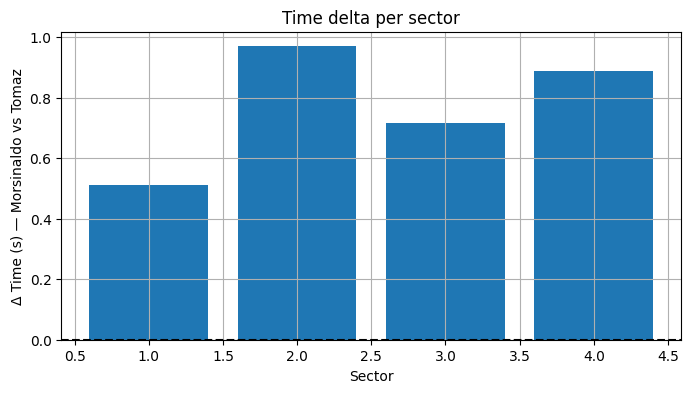

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(
    sectors_AB["Sector"],
    sectors_AB["DeltaTime_s"],
)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Sector")
plt.ylabel("Δ Time (s) — Morsinaldo vs Tomaz")
plt.title("Time delta per sector")
plt.grid(True)
plt.show()


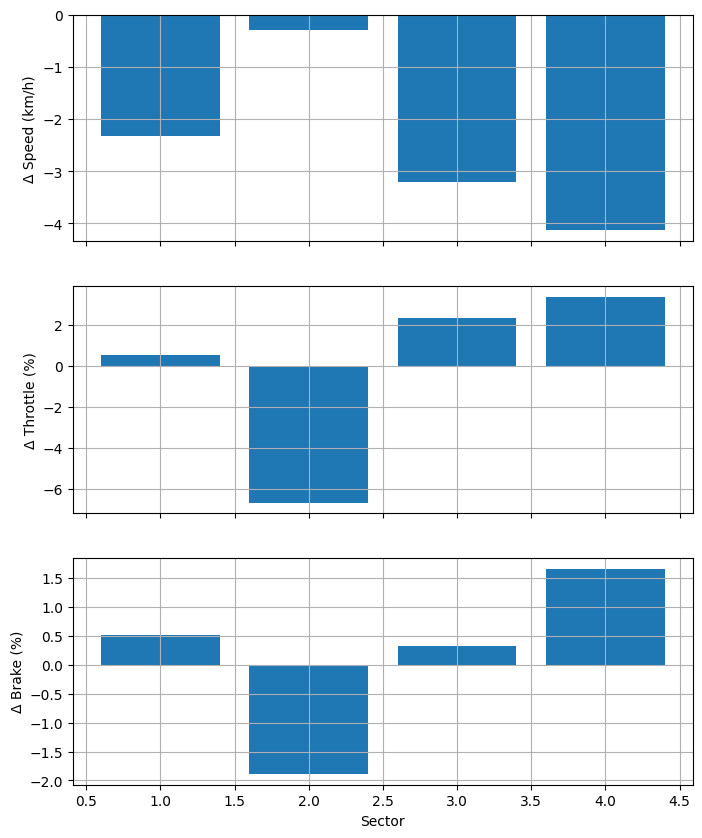

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax[0].bar(sectors_AB["Sector"], sectors_AB["MeanSpeedDiff_kph"])
ax[0].set_ylabel("Δ Speed (km/h)")
ax[0].grid(True)

ax[1].bar(sectors_AB["Sector"], sectors_AB["MeanThrottleDiff_pct"])
ax[1].set_ylabel("Δ Throttle (%)")
ax[1].grid(True)

ax[2].bar(sectors_AB["Sector"], sectors_AB["MeanBrakeDiff_pct"])
ax[2].set_ylabel("Δ Brake (%)")
ax[2].set_xlabel("Sector")
ax[2].grid(True)

plt.show()



## New Heuristics



## Base Functions 

In [14]:
from scipy.signal import savgol_filter

## Calcular Derivadas
def compute_derivatives(sec: dict):
    t = sec["t_rel"]
    dt = np.mean(np.diff(t))

    brake = sec["brake"]
    throttle = sec["throttle"]
    steer = sec["steering"]
    yaw = sec["yaw_rate"]

    brake_rate = np.gradient(brake, dt)
    throttle_rate = np.gradient(throttle, dt)

    # Suavização (essencial)
    brake_rate = savgol_filter(brake_rate, 9, 3)
    throttle_rate = savgol_filter(throttle_rate, 9, 3)

    return brake_rate, throttle_rate

# Braking Heuristics
def braking_heuristics(sec: dict, brake_rate):
    d = {}

    brake_mask = sec["brake"] > 0.05  # 5%

    if np.any(brake_mask):
        d["BrakeRampRate"] = float(
            np.quantile(brake_rate[brake_mask], 0.95)
        )

        d["BrakeConsistency"] = float(
            np.var(brake_rate[brake_mask])
        )

        d["BrakeEfficiency"] = float(
            abs(np.min(sec["long_accel"][brake_mask])) /
            np.max(sec["brake"][brake_mask])
        )
    else:
        d["BrakeRampRate"] = 0.0
        d["BrakeConsistency"] = 0.0
        d["BrakeEfficiency"] = 0.0

    return d

#Rotation Heuristics:
#measure rotation quality, rotation vs minimum speed and steering input for yaw
def rotation_heuristics(sec: dict):
    d = {}

    speed = sec["speed"]
    yaw = sec["yaw_rate"]
    steer = sec["steering"]

    idx_vmin = np.argmin(speed)
    idx_mrp = np.argmax(np.abs(yaw))

    d["Vmin"] = float(speed[idx_vmin])
    d["Delta_MRP_Vmin"] = float(sec["t_rel"][idx_vmin] - sec["t_rel"][idx_mrp])

    if np.mean(np.abs(steer)) > 1e-3:
        d["RotationEfficiency"] = float(
            np.mean(np.abs(yaw)) / np.mean(np.abs(steer))
        )
    else:
        d["RotationEfficiency"] = 0.0

    return d


##acceleration heuristics
## measures throttle attack rate, smoothness and conflict with steering
def acceleration_heuristics(sec: dict, throttle_rate):
    d = {}

    throttle_mask = sec["throttle"] > 0.05

    if np.any(throttle_mask):
        d["ThrottleAttackRate"] = float(
            np.quantile(throttle_rate[throttle_mask], 0.95)
        )

        d["ThrottleSmoothness"] = float(
            1.0 / np.var(throttle_rate[throttle_mask])
        )

        d["ThrottleSteerConflict"] = float(
            np.mean(sec["throttle"] * np.abs(sec["steering"]))
        )
    else:
        d["ThrottleAttackRate"] = 0.0
        d["ThrottleSmoothness"] = 0.0
        d["ThrottleSteerConflict"] = 0.0

    return d

# Sector Heuristics
#transform sector data into heuristics
def sector_heuristics(sec_raw: dict) -> dict:
    sec = {
        "t_rel": sec_raw["t_rel"],
        "speed": sec_raw["speed"],
        "brake": sec_raw["brake"],
        "throttle": sec_raw["throttle"],
        "steering": sec_raw["SteeringWheelAngle"],
        "yaw_rate": sec_raw["YawRate"],
        "long_accel": sec_raw["LongAccel"],
    }

    brake_rate, throttle_rate = compute_derivatives(sec)

    h = {}
    h.update(braking_heuristics(sec, brake_rate))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate))
    return h

#compute heuristics for all sectors for one driver
#interp = saída do align_lap_by_dist
#sector_heuristics = aquela função grande que já criamos
#saída = 1 linha por setor

def compute_sector_heuristics(
    interp: dict,
    n_sectors: int
) -> pd.DataFrame:

    n = len(interp["t_rel"])
    slices = sector_slices(n, n_sectors)

    rows = []

    for sid, sl in enumerate(slices, start=1):
        sec_raw = {k: v[sl] for k, v in interp.items()}

        h = sector_heuristics(sec_raw)

        h_row = {"Sector": sid}
        h_row.update(h)
        rows.append(h_row)

    return pd.DataFrame(rows)




## Driver A - Heuristics

In [15]:
heur_A = compute_sector_heuristics(
    interp=interp_A,
    n_sectors=N_SECTORS
)

heur_A.insert(0, "Pilot", "A")
heur_A


,Pilot,Sector,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict
0,A,1,86.263929,2407.541421,0.177751,106.637928,0.120004,0.457984,121.046493,0.000228,34.283182
1,A,2,89.126640,3266.768658,0.186627,56.374464,-1.511929,0.572464,63.712143,0.000481,25.146625
2,A,3,128.953427,6166.985793,0.160412,87.107886,0.298246,0.826539,21.755823,0.000699,14.306291
3,A,4,114.089622,5423.285560,0.168989,95.509100,-1.421082,0.912103,19.909506,0.000637,19.668379


## Driver B - Heuristics

In [16]:
heur_B = compute_sector_heuristics(
    interp=interp_B,
    n_sectors=N_SECTORS
)

heur_B.insert(0, "Pilot", "B")
heur_B


,Pilot,Sector,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict
0,B,1,61.091674,1727.816709,0.181485,107.966914,0.246925,0.611163,130.519712,0.000243,25.913618
1,B,2,74.549663,1825.667985,0.159812,56.920429,0.955061,0.574282,70.927478,0.000573,20.569854
2,B,3,216.947092,11799.004981,0.154668,74.113086,0.998448,0.816892,0.000000,0.000599,17.875358
3,B,4,233.195797,16213.991921,0.157054,80.032333,-2.022082,0.854960,0.000000,0.000621,20.038809


# Driver Feedback Rules

In [19]:
def generate_sector_feedback(row, thresholds=None):
    feedback = []

    # =========================
    # 🟥 FREIAGEM (ENTRY PHASE)
    # =========================

    # F1 — Frenagem agressiva e instável
    if row["Δ_BrakeRampRate"] > 20 and row["Δ_BrakeConsistency"] > 1000:
        feedback.append(
            "Entrada de freio agressiva e pouco modulada, reduzindo a estabilidade do carro."
        )

    # F2 — Frenagem conservadora e ineficiente
    if row["Δ_BrakeRampRate"] < -20 and row["Δ_BrakeEfficiency"] < -0.02:
        feedback.append(
            "Aplicação de freio excessivamente progressiva, com baixa eficiência de desaceleração."
        )

    # F3 — Boa frenagem que não vira rotação
    if row["Δ_BrakeEfficiency"] > 0.0 and row["Δ_RotationEfficiency"] < -0.03:
        feedback.append(
            "Apesar de uma frenagem eficiente, essa desaceleração não está sendo convertida em rotação do carro."
        )

    # F4 — Instabilidade direcional na frenagem
    if row["Δ_BrakeConsistency"] > 2000 and row["Δ_BrakeRampRate"] > 0:
        feedback.append(
            "Oscilações no pedal de freio indicam instabilidade direcional durante a frenagem."
        )

    # =========================
    # 🟧 ROTAÇÃO & ÁPICE
    # =========================

    # R1 — Velocidade mínima alta, mas rotação tardia
    if row["Δ_Vmin"] > 0.5 and row["Δ_Delta_MRP_Vmin"] > 1.0:
        feedback.append(
            "Boa velocidade mínima, mas a rotação do carro acontece tarde em relação ao ápice."
        )

    # R2 — Rotação precoce que mata Vmin
    if row["Δ_Vmin"] < -5.0 and row["Δ_Delta_MRP_Vmin"] < -1.0:
        feedback.append(
            "A rotação acontece cedo demais, reduzindo a velocidade no centro da curva."
        )

    # R3 — Rotação ineficiente por excesso de volante
    if row["Δ_RotationEfficiency"] < -0.05:
        feedback.append(
            "Uso excessivo de volante sem retorno proporcional em rotação do carro."
        )

    # R4 — Boa rotação com baixa velocidade mínima
    if row["Δ_RotationEfficiency"] > 0.05 and row["Δ_Vmin"] < 0:
        feedback.append(
            "O carro rotaciona bem, mas com sacrifício excessivo de velocidade mínima."
        )

    # =========================
    # 🟩 ACELERAÇÃO (EXIT PHASE)
    # =========================

    # A1 — Aceleração insegura com volante aplicado
    if row["Δ_ThrottleAttackRate"] < -10 and row["Δ_ThrottleSteerConflict"] > 2.0:
        feedback.append(
            "A aplicação do acelerador ocorre com excesso de esterço, comprometendo a tração na saída."
        )

    # A2 — Aceleração agressiva e pouco suave
    if row["Δ_ThrottleAttackRate"] > 15 and row["Δ_ThrottleSmoothness"] < -0.00005:
        feedback.append(
            "Aplicação do acelerador muito agressiva e pouco progressiva na saída da curva."
        )

    # A3 — Boa rotação, mas aceleração tardia
    if row["Δ_RotationEfficiency"] > 0.03 and row["Δ_ThrottleAttackRate"] < 0:
        feedback.append(
            "Mesmo com boa rotação do carro, a retomada de aceleração acontece de forma tardia."
        )

    # A4 — Perda de tração por excesso de confiança
    if row["Δ_ThrottleAttackRate"] > 10 and row["Δ_ThrottleSteerConflict"] > 3.0:
        feedback.append(
            "O acelerador é aplicado cedo demais com o volante ainda carregado, causando perda de eficiência na saída."
        )

    # =========================
    # 🟦 COERÊNCIA GLOBAL DO SETOR
    # =========================

    # C1 — Setor tecnicamente bom, mas mal conectado
    if (
        row["Δ_BrakeEfficiency"] > 0
        and row["Δ_RotationEfficiency"] > 0
        and row["Δ_ThrottleAttackRate"] < 0
    ):
        feedback.append(
            "O setor apresenta boa base técnica, mas falta fluidez na transição entre rotação e aceleração."
        )

    # C2 — Estilo excessivamente conservador
    if (
        row["Δ_BrakeRampRate"] < 0
        and row["Δ_ThrottleAttackRate"] < 0
        and row["Δ_Vmin"] < 0
    ):
        feedback.append(
            "Abordagem excessivamente conservadora ao longo do setor, com impacto direto no tempo."
        )

    return feedback


In [21]:
# Merge por setor
df_delta = (
    heur_B
    .merge(
        heur_A,
        on="Sector",
        suffixes=("_B", "_A")
    )
)

# Calcula os deltas (B - A)
for col in heur_A.columns:
    if col in ["Pilot", "Sector"]:
        continue
    df_delta[f"Δ_{col}"] = df_delta[f"{col}_B"] - df_delta[f"{col}_A"]

df_delta

for _, row in df_delta.iterrows():
    print(f"\nSetor {row['Sector']}:")
    msgs = generate_sector_feedback(row)
    if msgs:
        for m in msgs:
            print(" -", m)
    else:
        print(" - Setor bem executado, sem desvios relevantes.")



Setor 1:
 - Setor bem executado, sem desvios relevantes.

Setor 2:
 - Boa velocidade mínima, mas a rotação do carro acontece tarde em relação ao ápice.

Setor 3:
 - Entrada de freio agressiva e pouco modulada, reduzindo a estabilidade do carro.
 - Oscilações no pedal de freio indicam instabilidade direcional durante a frenagem.
 - A aplicação do acelerador ocorre com excesso de esterço, comprometendo a tração na saída.

Setor 4:
 - Entrada de freio agressiva e pouco modulada, reduzindo a estabilidade do carro.
 - Oscilações no pedal de freio indicam instabilidade direcional durante a frenagem.
 - Uso excessivo de volante sem retorno proporcional em rotação do carro.
